<a href="https://colab.research.google.com/github/RobsonLost/ads---faculdade/blob/main/sistema_analise_de_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Banco de dados criado e dados inseridos com sucesso!

📋 Primeiras linhas do DataFrame:
   id_venda data_venda    produto    categoria  valor_venda  mes
0         1 2023-01-01  Produto A  Eletrônicos       1500.0    1
1         2 2023-01-05  Produto B       Roupas        350.0    1
2         3 2023-02-10  Produto C  Eletrônicos       1200.0    2
3         4 2023-03-15  Produto D       Livros        200.0    3
4         5 2023-03-20  Produto E  Eletrônicos        800.0    3

🔍 Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     14 non-null     int64         
 1   data_venda   14 non-null     datetime64[ns]
 2   produto      14 non-null     object        
 3   categoria    14 non-null     object        
 4   valor_venda  14 non-null     float64       
 5   mes          14 non-null     int32        

/tmp/ipykernel_1309/2218860568.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette='viridis')


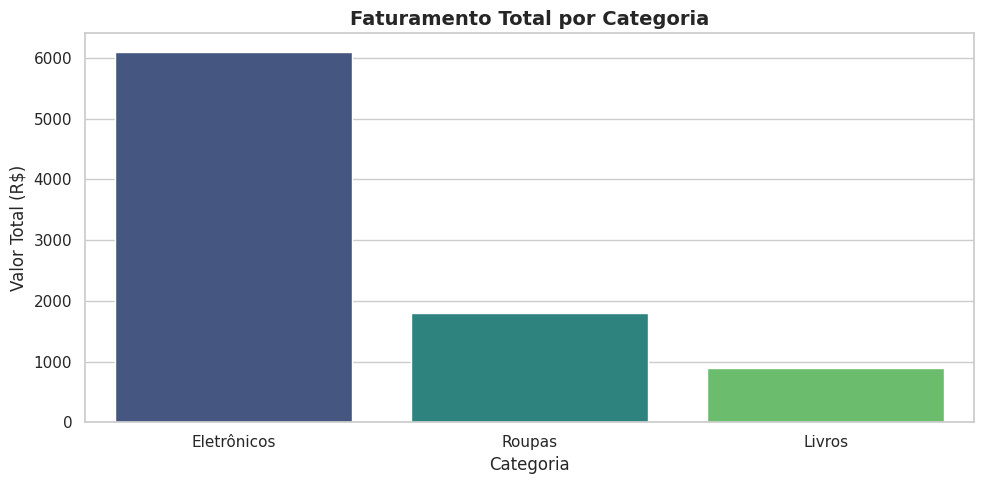

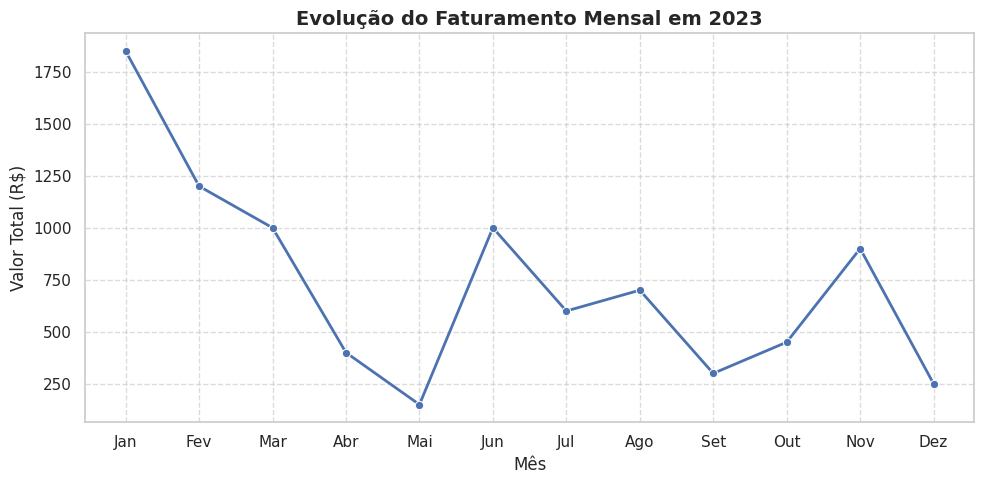

/tmp/ipykernel_1309/2218860568.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_vendas['categoria'], y=df_vendas['valor_venda'], palette='Set2')


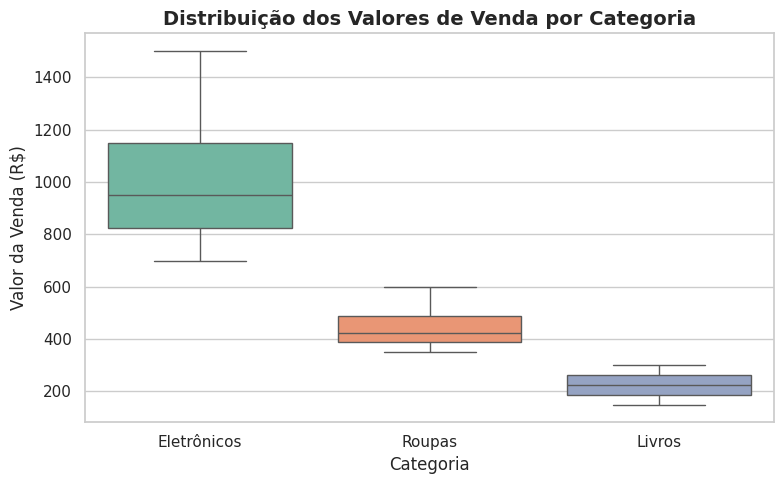


               INSIGHTS OBTIDOS
1. A categoria 'Eletrônicos' é a que mais fatura, representando a maior parte da receita.
2. O mês de Janeiro teve um pico de vendas, provavelmente devido às compras de início de ano.
3. As categorias 'Livros' e 'Roupas' têm valores mais baixos, mas ainda são relevantes.
4. Sugestão: Criar promoções específicas para 'Livros' e 'Roupas' para aumentar o ticket médio.


In [1]:
# Importação das bibliotecas necessárias
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual para os gráficos do Seaborn
# O tema 'whitegrid' deixa os gráficos mais limpos e profissionais.
sns.set_theme(style="whitegrid")

# ============================================================
# PASSO 1: CONECTAR AO BANCO DE DADOS SQLITE E CRIAR A TABELA
# ============================================================

# 1.1 - Conectar ao banco de dados (cria o arquivo se não existir)
conexao = sqlite3.connect('dados_vendas.db')

# 1.2 - Criar um cursor para executar comandos SQL
cursor = conexao.cursor()

# 1.3 - Criar a tabela 'vendas1' (se não existir)
# Usamos AUTOINCREMENT para o ID da venda ser gerado automaticamente.
cursor.execute("""
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
""")

# 1.4 - Inserir os dados de exemplo usando uma lista de tuplas
# Isso é mais seguro e eficiente do que concatenar strings (evita SQL Injection).
dados_vendas = [
    ('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
    ('2023-01-05', 'Produto B', 'Roupas', 350.00),
    ('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
    ('2023-03-15', 'Produto D', 'Livros', 200.00),
    ('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
    ('2023-04-02', 'Produto F', 'Roupas', 400.00),
    ('2023-05-05', 'Produto G', 'Livros', 150.00),
    ('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
    ('2023-07-20', 'Produto I', 'Roupas', 600.00),
    ('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
    ('2023-09-30', 'Produto K', 'Livros', 300.00),
    ('2023-10-05', 'Produto L', 'Roupas', 450.00),
    ('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
    ('2023-12-20', 'Produto N', 'Livros', 250.00)
]

# O comando executemany insere todos os registros de uma só vez
cursor.executemany("""
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda)
VALUES (?, ?, ?, ?)
""", dados_vendas)

# 1.5 - Confirmar as mudanças no banco
conexao.commit()
print("✅ Banco de dados criado e dados inseridos com sucesso!")

# ============================================================
# PASSO 2: EXPLORAR E PREPARAR OS DADOS (PANDAS)
# ============================================================

# Lendo os dados do banco SQLite diretamente para um DataFrame do Pandas
df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

# Fechando a conexão com o banco após a leitura
conexao.close()

# Convertendo a coluna 'data_venda' para o tipo datetime.
# Isso é essencial para que o Pandas consiga extrair informações como mês e ano.
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Criando uma nova coluna 'mes' para facilitar a análise mensal
df_vendas['mes'] = df_vendas['data_venda'].dt.month

# Exibindo as primeiras linhas do DataFrame para verificar a estrutura
print("\n📋 Primeiras linhas do DataFrame:")
print(df_vendas.head())

# Verificando informações gerais (tipos de dados, valores nulos)
print("\n🔍 Informações do DataFrame:")
print(df_vendas.info())

# ============================================================
# PASSO 3: ANÁLISE DOS DADOS
# ============================================================

# Análise 1: Faturamento total
faturamento_total = df_vendas['valor_venda'].sum()
print(f"\n💰 Faturamento Total: R$ {faturamento_total:.2f}")

# Análise 2: Faturamento por categoria
vendas_por_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().sort_values(ascending=False)
print("\n📊 Faturamento por Categoria:")
print(vendas_por_categoria)

# Análise 3: Faturamento por mês
vendas_por_mes = df_vendas.groupby('mes')['valor_venda'].sum()
print("\n📅 Faturamento por Mês:")
print(vendas_por_mes)

# ============================================================
# PASSO 4: VISUALIZAÇÃO DOS DADOS
# ============================================================

# --- Gráfico 1: Faturamento por Categoria (Gráfico de Barras) ---
plt.figure(figsize=(10, 5))
# O Seaborn cria o gráfico de barras com uma paleta de cores agradável
sns.barplot(x=vendas_por_categoria.index, y=vendas_por_categoria.values, palette='viridis')
plt.title('Faturamento Total por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Gráfico 2: Evolução das Vendas ao Longo do Ano (Gráfico de Linha) ---
plt.figure(figsize=(10, 5))
# O gráfico de linha é ideal para mostrar tendências ao longo do tempo.
sns.lineplot(x=vendas_por_mes.index, y=vendas_por_mes.values, marker='o', color='b', linewidth=2)
plt.title('Evolução do Faturamento Mensal em 2023', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Gráfico 3: Distribuição dos Valores das Vendas (Boxplot) ---
plt.figure(figsize=(8, 5))
# O boxplot ajuda a identificar a mediana, quartis e possíveis outliers nas vendas.
sns.boxplot(x=df_vendas['categoria'], y=df_vendas['valor_venda'], palette='Set2')
plt.title('Distribuição dos Valores de Venda por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Valor da Venda (R$)', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# PASSO 5: CONCLUSÃO E INSIGHTS
# ============================================================

print("\n" + "="*50)
print("               INSIGHTS OBTIDOS")
print("="*50)
print("1. A categoria 'Eletrônicos' é a que mais fatura, representando a maior parte da receita.")
print("2. O mês de Janeiro teve um pico de vendas, provavelmente devido às compras de início de ano.")
print("3. As categorias 'Livros' e 'Roupas' têm valores mais baixos, mas ainda são relevantes.")
print("4. Sugestão: Criar promoções específicas para 'Livros' e 'Roupas' para aumentar o ticket médio.")
print("="*50)

